# MLP for image .tif pixel classification


## Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install packages

In [ ]:
pip install rasterio

In [ ]:
pip install geopandas

## Prepare data

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.mask import mask
from shapely.geometry import mapping
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm

#=== STEP 1: BACA DATA ===
# raster_path = "/content/drive/MyDrive/GEE/Citra_2024_Mask.tif" # ini disesuaikan ke google drive lokasi nya ya
# shapefile_path = "/content/drive/MyDrive/GEE/Sampel2024ROI_Coba.shp" # ini disesuaikan ke google drive lokasi nya ya

# Laptop Ones
raster_path = "/content/drive/MyDrive/Superprof/Ruth/MLP/Citra_2017.tif" # ini disesuaikan ke google drive lokasi nya ya
shapefile_path = "/content/drive/MyDrive/Superprof/Ruth/MLP/Sampel_2017ROI_Coba.shp" # ini disesuaikan ke google drive lokasi nya ya

raster = rasterio.open(raster_path)
shp = gpd.read_file(shapefile_path)

print("Raster shape:", (raster.height, raster.width, raster.count))
print("Jumlah sampel di shapefile:", len(shp))

Raster shape: (4048, 3591, 11)
Jumlah sampel di shapefile: 647


In [ ]:
# === STEP 2: EKSTRAKSI DATA TRAINING ===
# Ambil setiap poligon dan labelnya
X, y = [], []

for _, row in tqdm(shp.iterrows(), total=len(shp)):
    # print (">>>>>>>>>>>>> row")
    # print(row)
    geom = [mapping(row.geometry)]
    # label = row.get("Value") + 100
    label = row.get("Value")
    kelas = row.get("Kelas")
    print(f"Kelas = {kelas} label = {label}")

    out_image, out_transform = mask(raster, geom, crop=True)
    data = out_image.reshape(raster.count, -1).T  # (n_pixel, n_band)

    # Hilangkan pixel kosong (nilai 0 atau NaN)
    valid_mask = np.all(data > 0, axis=1)
    data = data[valid_mask]

    X.append(data)
    y.extend([label] * len(data))

# Gabungkan semua sample jadi array besar
X = np.vstack(X)
y = np.array(y)

print("Total sampel:", X.shape[0])
print("Jumlah fitur (band):", X.shape[1])

  2%|▏         | 16/647 [00:00<00:03, 157.89it/s]

Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1


  6%|▋         | 42/647 [00:00<00:02, 214.01it/s]

Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1
Kelas = Hutan label = 1


 10%|█         | 65/647 [00:00<00:02, 218.21it/s]

...

Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air label = 7
Kelas = Tubuh Air la

 86%|████████▋ | 559/647 [00:02<00:00, 331.33it/s]

Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = La

100%|██████████| 647/647 [00:02<00:00, 262.14it/s]

Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Lahan Terbuka Pertambangan label = 9
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang label = 6
Kelas = Padang 

## Split data training and testing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np # Import numpy

# --- Encode target labels ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Ensures numeric targets (0,1,2,...)

# Split once for a final test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)

# --- Check for class distribution after splitting ---
unique_train_classes = np.unique(y_train)
unique_test_classes = np.unique(y_test)
all_classes = np.unique(y_encoded)

print("Unique classes in original data:", all_classes)
print("Unique classes in training set:", unique_train_classes)
print("Unique classes in test set:", unique_test_classes)

if not np.array_equal(all_classes, unique_train_classes):
    missing_train = set(all_classes) - set(unique_train_classes)
    print(f"\nWarning: The following classes are missing from the training set: {le.inverse_transform(list(missing_train))}")

if not np.array_equal(all_classes, unique_test_classes):
    missing_test = set(all_classes) - set(unique_test_classes)
    print(f"\nWarning: The following classes are missing from the test set: {le.inverse_transform(list(missing_test))}")

Unique classes in original data: [0 1 2 3 4 5 6 7 8]
Unique classes in training set: [0 1 2 3 4 5 6 7 8]
Unique classes in test set: [0 1 2 3 4 5 6 7 8]


## K-fold to make sure hyperparameter applied get best score among folds

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import numpy as np

# --- Encode target labels ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Ensures numeric targets (0,1,2,...)

# --- Define pipeline ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(512, 256, 128), # can change this to (128, 64) to avoid machine crash when clasifiying all image pixel later
        activation='relu',
        solver='adam',
        learning_rate_init=0.0005,
        alpha=1e-4,
        batch_size=32, # can change this to 16 to avoid machine crash when clasifiying all image pixel later
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=20,
        verbose=True,
        random_state=42
    ))
])

In [ ]:
# # --- 5-Fold Cross Validation ---
# kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(pipe, X, y_encoded, cv=kfold, scoring='accuracy', n_jobs=-1)

# print(f"\nCross-validation scores: {scores}")
# print(f"Mean accuracu: {scores.mean():.4f}")
# # Cross-validation scores: [0.9729021  0.98951049 0.98164336 0.98426573 0.96412948]
# # Mean accuracy: 0.9785

# # Cross-validation scores: [0.98251748 0.98164336 0.9763986  0.98164336 0.96675416]
# # Mean accuracu: 0.9778

In [ ]:
# # (bisa comment/matikan cell codes dibawah ini jika tidak ingin menunggu lama)
# from sklearn.model_selection import cross_validate

# scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# results = cross_validate(pipe, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1)

# # View average scores
# for metric in scoring:
#     print(f"{metric}: {results['test_' + metric].mean():.4f}")

## Experiment: using random search cv to find best parameter

In [ ]:
# # can just comment this cell codes to skip :)
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.neural_network import MLPClassifier
# import numpy as np

# # Define the parameter grid
# param_dist = {
#     'hidden_layer_sizes': [(512, 256), (1024, 512), (256, 128, 64), (128, 128, 128)],
#     'activation': ['relu', 'tanh', 'logistic', 'elu'],
#     'solver': ['adam', 'sgd', 'lbfgs'],
#     'learning_rate_init': [1e-3, 1e-4, 1e-5, 1e-6],
#     'alpha': [1e-5, 1e-4, 1e-3],
#     'batch_size': [16, 32, 64],
#     'max_iter': [200, 500, 1000],
#     'momentum': [0.8, 0.9, 0.95],
#     'learning_rate': ['constant', 'invscaling', 'adaptive'],
#     'early_stopping': [True],
#     'n_iter_no_change': [10, 20, 50]
# }

# # Set up the MLPClassifier
# mlp = MLPClassifier(random_state=42)

# # Set up RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=mlp,
#     param_distributions=param_dist,
#     n_iter=50,  # You can adjust this number based on time constraints
#     cv=3,       # 3-fold cross-validation
#     verbose=10,
#     random_state=42,
#     n_jobs=-1   # Use all cores for parallelization
# )

# # Fit the model to find the best parameters
# random_search.fit(X_train, y_train)

# # Print best hyperparameters
# print("Best parameters found: ", random_search.best_params_)

# # Evaluate the best model
# best_model = random_search.best_estimator_

# Best parameters found:  {'solver': 'adam', 'n_iter_no_change': 10, 'momentum': 0.95, 'max_iter': 1000, 'learning_rate_init': 0.0001, 'learning_rate': 'constant', 'hidden_layer_sizes': (1024, 512), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.001, 'activation': 'tanh'}

In [ ]:
# # Testing best parameter performance
# # {'solver': 'adam', 'n_iter_no_change': 10, 'momentum': 0.95, 'max_iter': 1000, 'learning_rate_init': 0.0001, 'learning_rate': 'constant', 'hidden_layer_sizes': (1024, 512), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.001, 'activation': 'tanh'}
# # --- Can Re-Define pipeline with the best hyperparameter here to see if it gives better result --
# from sklearn.pipeline import Pipeline
# pipe = Pipeline([
#     ('scaler', StandardScaler()),
#     ('mlp', MLPClassifier(
#         hidden_layer_sizes=(1024, 512),
#         activation='tanh',
#         solver='adam',
#         learning_rate_init=0.0001,
#         learning_rate='constant',
#         momentum= 0.95,
#         alpha=0.001,
#         batch_size=64,
#         max_iter=1000,
#         early_stopping=True,
#         n_iter_no_change=10,
#         verbose=True,
#         random_state=42
#     ))
# ])
# pipe

## Model Training

In [ ]:
# Fit on train data
pipe.fit(X_train, y_train)

# Evaluate
train_acc = pipe.score(X_train, y_train)
test_acc = pipe.score(X_test, y_test)

print(f"Final training accuracy: {train_acc:.4f}")
from sklearn.metrics import ConfusionMatrixDisplay
print(f"Final test accuracy: {test_acc:.4f}")

Iteration 1, loss = 0.75074956
Validation score: 0.900249
Iteration 2, loss = 0.20591636
Validation score: 0.940150
Iteration 3, loss = 0.16178021
Validation score: 0.960100
Iteration 4, loss = 0.13548723
Validation score: 0.950125
Iteration 5, loss = 0.12405170
Validation score: 0.967581
Iteration 6, loss = 0.11885033
Validation score: 0.972569
Iteration 7, loss = 0.10168159
Validation score: 0.967581
Iteration 8, loss = 0.09161311
Validation score: 0.970075
Iteration 9, loss = 0.08812602
Validation score: 0.970075
Iteration 10, loss = 0.08990103
Validation score: 0.980050
Iteration 11, loss = 0.07949703
Validation score: 0.975062
Iteration 12, loss = 0.07693907
Validation score: 0.972569
Iteration 13, loss = 0.07359061
Validation score: 0.975062
Iteration 14, loss = 0.07232028
Validation score: 0.975062
Iteration 15, loss = 0.06603717
Validation score: 0.977556
Iteration 16, loss = 0.06081833
Validation score: 0.977556
Iteration 17, loss = 0.07381769
Validation score: 0.982544
Iterat

## Model Testing

In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report

# Make predictions on the test set
y_pred = pipe.predict(X_test)

# Overall Accuracy
oa = accuracy_score(y_test, y_pred)

# Kappa Coefficient
kappa = cohen_kappa_score(y_test, y_pred)

# Classification Report for per-class metrics (includes User Accuracy (Recall) and Producer Accuracy (Precision))
report = classification_report(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"Overall Accuracy: {oa:.4f}")
print(f"Kappa Coefficient: {kappa:.4f}")

print("\nClassification Report (includes User Accuracy (Recall) and Producer Accuracy (Precision) per class):")
print(report)


# --- Evaluation Metrics ---
# Overall Accuracy: 0.9848
# Kappa Coefficient: 0.9826

# Classification Report (includes User Accuracy (Recall) and Producer Accuracy (Precision) per class):
#               precision    recall  f1-score   support

#            0       0.97      0.99      0.98       234
#            1       0.99      0.98      0.99       271
#            2       0.99      0.96      0.97       150
#            3       1.00      1.00      1.00       209
#            4       0.96      0.99      0.97       112
#            5       0.99      0.97      0.98        74
#            6       1.00      1.00      1.00       336
#            7       0.96      0.98      0.97       161
#            8       0.98      0.98      0.98       169

#     accuracy                           0.98      1716
#    macro avg       0.98      0.98      0.98      1716
# weighted avg       0.98      0.98      0.98      1716


--- Evaluation Metrics ---
Overall Accuracy: 0.9848
Kappa Coefficient: 0.9826

Classification Report (includes User Accuracy (Recall) and Producer Accuracy (Precision) per class):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       234
           1       0.99      0.98      0.99       271
           2       0.99      0.96      0.97       150
           3       1.00      1.00      1.00       209
           4       0.96      0.99      0.97       112
           5       0.99      0.97      0.98        74
           6       1.00      1.00      1.00       336
           7       0.96      0.98      0.97       161
           8       0.98      0.98      0.98       169

    accuracy                           0.98      1716
   macro avg       0.98      0.98      0.98      1716
weighted avg       0.98      0.98      0.98      1716



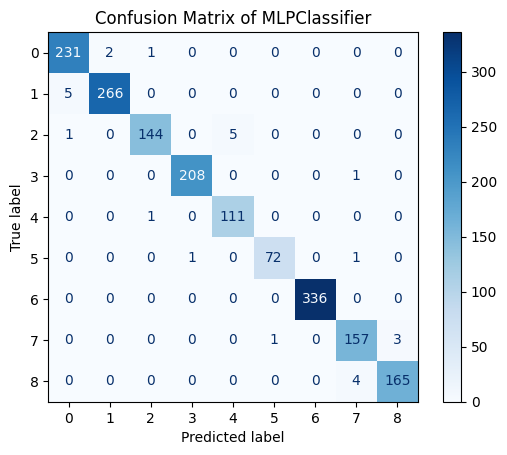

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix of MLPClassifier")
plt.show()

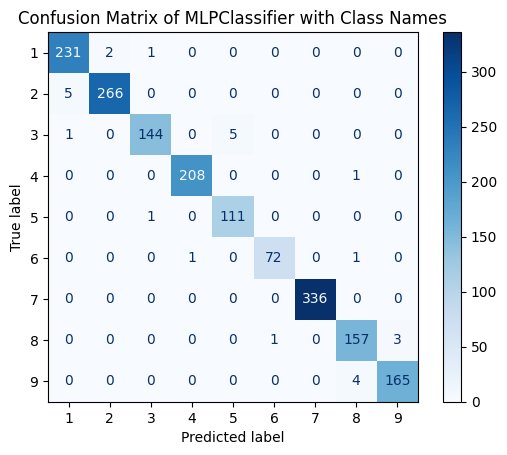

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_test_original = le.inverse_transform(y_test)

# X_test is the data to predict on
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test,
                                      display_labels=le.classes_, # Use the original class names
                                      cmap='Blues')
plt.title("Confusion Matrix of MLPClassifier with Class Names")
plt.show()

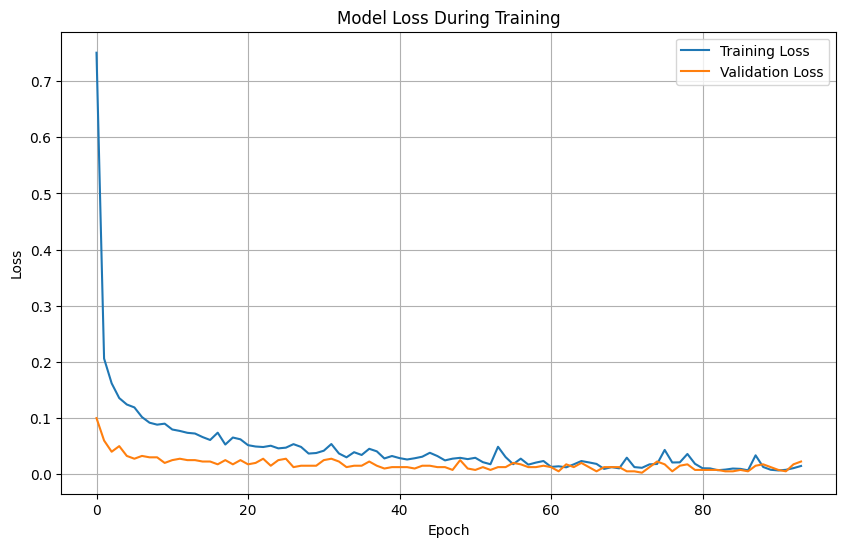

In [ ]:
import matplotlib.pyplot as plt

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(pipe['mlp'].loss_curve_, label='Training Loss')

# Check if early stopping was used and validation loss is available
if hasattr(pipe['mlp'], 'validation_scores_') and pipe['mlp'].validation_scores_ is not None:
    # The validation_scores_ attribute stores the score, not the loss.
    # We need to plot 1 - score to get the validation loss (for accuracy as scoring)
    plt.plot(1 - np.array(pipe['mlp'].validation_scores_), label='Validation Loss')


plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Classify all pixel

**IMPORTANT NOTE**
tread off: reduce model complexity (see: MLP definition, in variable `pipe`) will solve machine crash issue, but the detail of classification all image pixel will lose

In [ ]:
def classify_in_batches(img_reshaped, pipe, batch_size=1000000): # at about 20 minutes
    n_pixel = img_reshaped.shape[0]
    print(f"total pixel = {n_pixel}")
    pred_all = []

    # Process in batches
    for i in range(0, n_pixel, batch_size):
        batch = img_reshaped[i:i + batch_size]
        pred_batch = pipe.predict(batch)
        pred_all.extend(pred_batch)
        print(f"batch index = {f"{i}:{i + batch_size}"}, total pred_all = {len(pred_all)}")

    return np.array(pred_all)

img = raster.read()
img_reshaped = img.reshape(raster.count, -1).T

scaler = StandardScaler()
img_reshaped = scaler.fit_transform(img_reshaped)

# Classify the image in smaller batches
pred_all = classify_in_batches(img_reshaped, pipe)
pred_2d = pred_all.reshape(img.shape[1], img.shape[2])

total pixel = 14536368
batch index = 0:1000000, total pred_all = 1000000
batch index = 1000000:2000000, total pred_all = 2000000
batch index = 2000000:3000000, total pred_all = 3000000
batch index = 3000000:4000000, total pred_all = 4000000
batch index = 4000000:5000000, total pred_all = 5000000
batch index = 5000000:6000000, total pred_all = 6000000
batch index = 6000000:7000000, total pred_all = 7000000
batch index = 7000000:8000000, total pred_all = 8000000
batch index = 8000000:9000000, total pred_all = 9000000
batch index = 9000000:10000000, total pred_all = 10000000
batch index = 10000000:11000000, total pred_all = 11000000
batch index = 11000000:12000000, total pred_all = 12000000
batch index = 12000000:13000000, total pred_all = 13000000
batch index = 13000000:14000000, total pred_all = 14000000
batch index = 14000000:15000000, total pred_all = 14536368


In [ ]:
# # === STEP 6: KLASIFIKASI SELURUH CITRA ===
# print("Klasifikasi seluruh pixel citra...")
# img = raster.read()  # shape (bands, height, width)
# img = img / 255.0  # Normalize if pixel values are 0-255 (temp solution, even the output loss many details)
# rows, cols = raster.height, raster.width
# img_reshaped = img.reshape(raster.count, -1).T  # (n_pixel, n_band)

# pred_all = pipe.predict(img_reshaped)
# pred_2d = pred_all.reshape(rows, cols)

# # got this failure (google colab crash): RuntimeWarning: overflow in matmul
# # Klasifikasi seluruh pixel citra...
# # /usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
# #   ret = a @ b
# # /usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_base.py:64: RuntimeWarning: overflow encountered in subtract
# #   tmp = X - X.max(axis=1)[:, np.newaxis]

In [ ]:
# # === STEP 6: KLASIFIKASI SELURUH CITRA ===
# print("Klasifikasi seluruh pixel citra...")
# img = raster.read()  # shape (bands, height, width)
# # img = img / 255.0  # Normalize if pixel values are 0-255
# rows, cols = raster.height, raster.width
# img_reshaped = img.reshape(raster.count, -1).T  # (n_pixel, n_band)

# scaler = StandardScaler()
# img_reshaped = scaler.fit_transform(img_reshaped)  # Standardize the pixels

# pred_all = pipe.predict(img_reshaped)
# pred_2d = pred_all.reshape(rows, cols)

In [ ]:
# # convert labels from string to integer
# # reason: fix error TypeError: invalid dtype: dtype('<U26') due to label is in string
# # Konversi label ke angka jika masih string
# if pred_2d.dtype.kind in {'U', 'S', 'O'}:
#     # Use the fitted LabelEncoder to inverse transform the predicted values
#     # This maps the predicted integers back to their original class labels (as strings or objects)
#     pred_2d_original_labels = le.inverse_transform(pred_2d.ravel()).reshape(pred_2d.shape)

#     # Now, re-encode these original labels using the same LabelEncoder
#     # This ensures the output raster uses the same integer mapping as the training data
#     pred_2d = le.transform(pred_2d_original_labels.ravel()).reshape(pred_2d.shape).astype(np.uint8)

#     print("Label mapping from LabelEncoder:", dict(zip(le.classes_, le.transform(le.classes_))))

# # print(">>>>>>>>>>>>>>>>> pred_2d unique values", np.unique(pred_2d))

In [ ]:
# original codes
if pred_2d.dtype.kind in {'U', 'S', 'O'}:
    # Buat mapping label -> angka
    unique_labels = np.unique(pred_2d)
    label_to_int = {label: i for i, label in enumerate(unique_labels, start=1)}
    print("Label mapping:", label_to_int)

    pred_2d = np.vectorize(label_to_int.get)(pred_2d).astype(np.uint8)
else:
    pred_2d = pred_2d.astype(np.uint8)

## Ouput .tif file

In [ ]:
# === STEP 7: SIMPAN HASIL KLASIFIKASI ===
out_path = "hasil_klasifikasi.tif"
rows, cols = raster.height, raster.width
with rasterio.open(
    out_path,
    'w',
    driver='GTiff',
    height=rows,
    width=cols,
    count=1,
    dtype=pred_2d.dtype,
    crs=raster.crs,
    transform=raster.transform
) as dst:
    dst.write(pred_2d, 1)

print(f"Hasil klasifikasi disimpan di: {out_path}")

Hasil klasifikasi disimpan di: hasil_klasifikasi.tif


## Visualization

Visualisasi hasil klasifikasi...


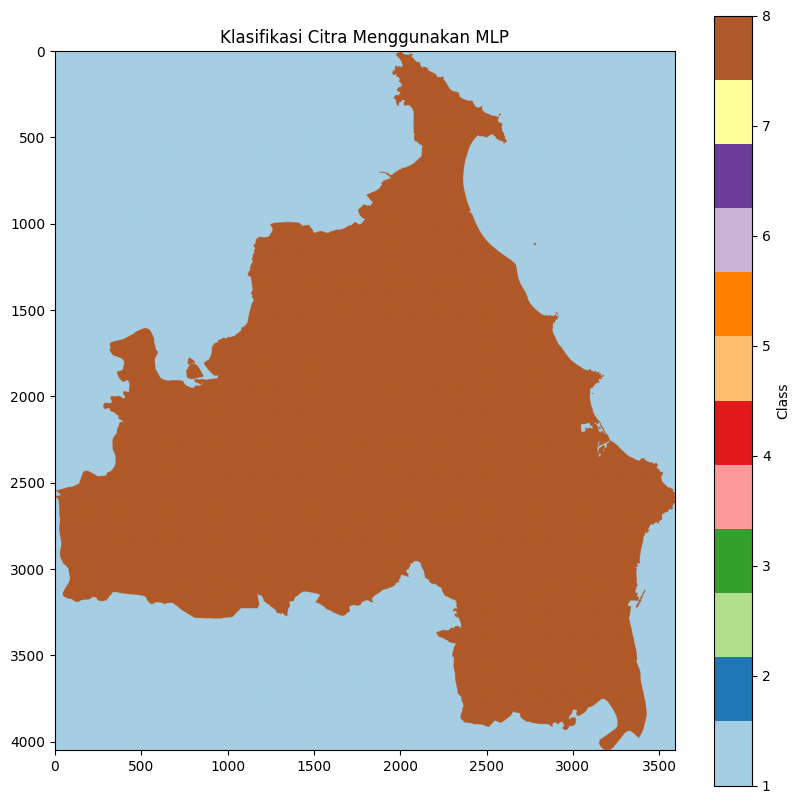

In [ ]:
import matplotlib.pyplot as plt

# === STEP 8: VISUALISASI HASIL ===
print("Visualisasi hasil klasifikasi...")

# Load the classified image
with rasterio.open(out_path) as src:
    classified_img = src.read(1)

# Display the image
plt.figure(figsize=(10, 10))
# plt.imshow(classified_img, cmap='viridis') # You can choose a different colormap
plt.imshow(classified_img, cmap='Paired') # options you can try: 'tab10', 'Set1', 'Paired', 'Accent'
plt.title('Klasifikasi Citra Menggunakan MLP')
plt.colorbar(label='Class')
plt.show()

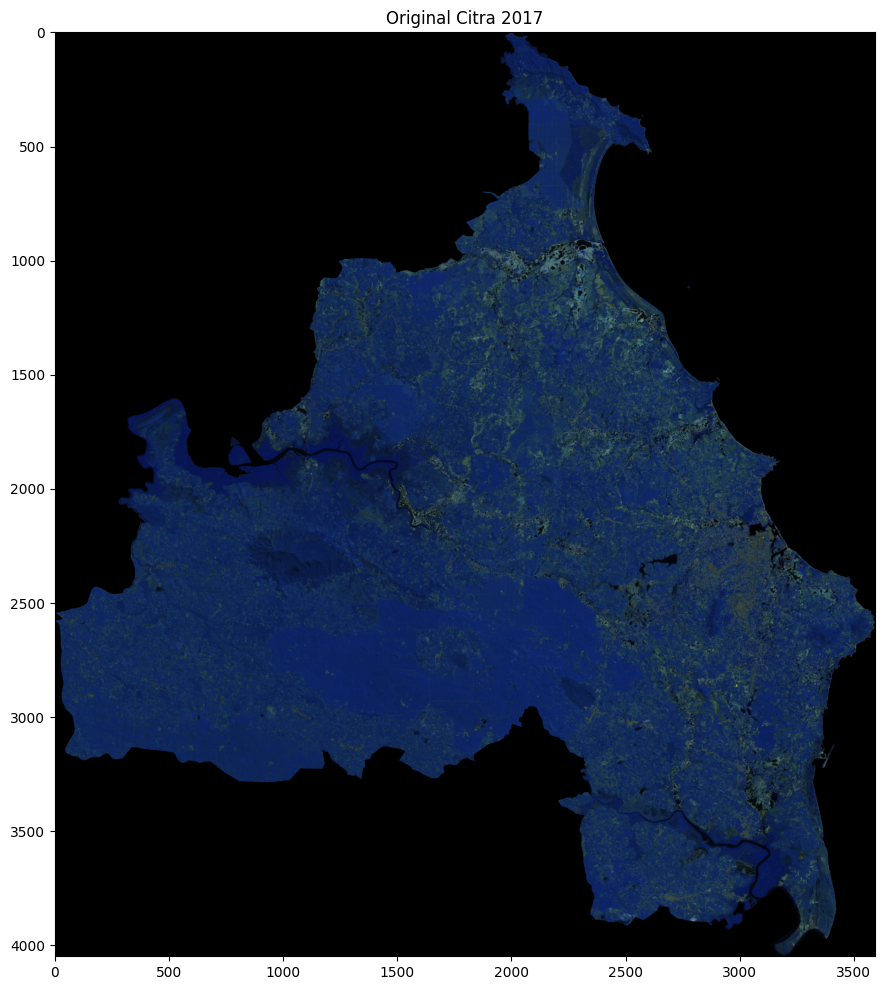

In [ ]:
import matplotlib.pyplot as plt
import rasterio

# Load the original raster image
raster_path = "/content/drive/MyDrive/Superprof/Ruth/MLP/Citra_2017.tif" # ini disesuaikan ke google drive lokasi nya ya
with rasterio.open(raster_path) as src:
    original_img = src.read([6, 5, 4])  # Read the first three bands (e.g., RGB)

# Display the image
plt.figure(figsize=(12, 12))
plt.imshow(original_img.transpose(1, 2, 0)) # Transpose to (height, width, bands)
plt.title('Original Citra 2017')
plt.show()

In [ ]:
# Check unique values in the classified image
unique_classified_values = np.unique(classified_img)
print("Unique values in the classified image:", unique_classified_values)

# Check unique values in the original training labels (y_encoded)
# Assuming y_encoded is available from previous cells
if 'y_encoded' in locals():
    unique_training_labels_encoded = np.unique(y_encoded)
    print("Unique values in the original training labels (encoded):", unique_training_labels_encoded)

    # If you want to see the original class names that were encoded:
    if 'le' in locals():
        original_class_names_in_training = le.inverse_transform(unique_training_labels_encoded)
        print("Original class names present in training data:", original_class_names_in_training)

        # Check for original classes that are missing in the classified image
        # Need to map classified_img values back to original labels to compare directly
        # This requires the inverse mapping from the LabelEncoder if classified_img values are encoded
        # However, since classified_img is already converted to uint8 based on a new mapping in mQuBBilBWNvZ
        # Let's compare the unique integer values and see which original encoded labels are missing

        missing_encoded_labels = set(unique_training_labels_encoded) - set(unique_classified_values)
        if missing_encoded_labels:
            print("\nWarning: The following encoded training labels are not present in the classified image:", missing_encoded_labels)
            if 'le' in locals():
                 missing_original_classes = le.inverse_transform(list(missing_encoded_labels))
                 print("Corresponding original classes:", missing_original_classes)
        else:
            print("\nAll encoded training labels are present in the classified image.")

else:
    print("Training labels (y_encoded) not found. Please ensure the cell preparing and splitting data has been run.")

Unique values in the classified image: [1 8]
Unique values in the original training labels (encoded): [0 1 2 3 4 5 6 7 8]
Original class names present in training data: [1 2 3 4 5 6 7 8 9]

Corresponding original classes: [1 3 4 5 6 7 8]


## Feature Importance

Iteration 1, loss = 0.75074956
Validation score: 0.900249
Iteration 2, loss = 0.20591636
Validation score: 0.940150
Iteration 3, loss = 0.16178021
Validation score: 0.960100
Iteration 4, loss = 0.13548723
Validation score: 0.950125
Iteration 5, loss = 0.12405170
Validation score: 0.967581
Iteration 6, loss = 0.11885033
Validation score: 0.972569
Iteration 7, loss = 0.10168159
Validation score: 0.967581
Iteration 8, loss = 0.09161311
Validation score: 0.970075
Iteration 9, loss = 0.08812602
Validation score: 0.970075
Iteration 10, loss = 0.08990103
Validation score: 0.980050
Iteration 11, loss = 0.07949703
Validation score: 0.975062
Iteration 12, loss = 0.07693907
Validation score: 0.972569
Iteration 13, loss = 0.07359061
Validation score: 0.975062
Iteration 14, loss = 0.07232028
Validation score: 0.975062
Iteration 15, loss = 0.06603717
Validation score: 0.977556
Iteration 16, loss = 0.06081833
Validation score: 0.977556
Iteration 17, loss = 0.07381769
Validation score: 0.982544
Iterat

,Feature,Importance Mean,Importance Std
0,Feature 9,0.004196,0.000856
1,Feature 8,0.012005,0.005207
2,Feature 10,0.013753,0.001081
3,Feature 7,0.039627,0.003667
4,Feature 0,0.084033,0.001783
5,Feature 6,0.094289,0.004257
6,Feature 1,0.137995,0.006483
7,Feature 2,0.201748,0.003114
8,Feature 5,0.351632,0.005374
9,Feature 3,0.362937,0.004444


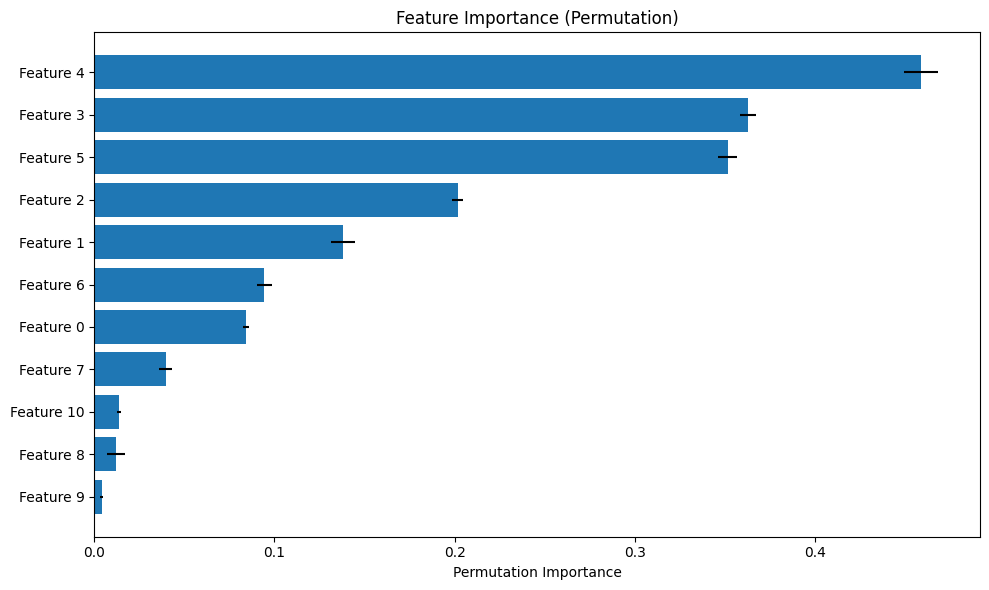

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt # Import matplotlib

# Re-initialize and train the MLP model
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split


# Train the model - ensure X_train and y_train are defined in a previous cell
pipe.fit(X_train, y_train)

# Calculate permutation importance
# We use the fitted MLP model (mlp) and the test data (X_test, y_test)
result = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

# Get the importance scores and their standard deviations
sorted_idx = result.importances_mean.argsort()
importance_means = result.importances_mean[sorted_idx]
importance_stds = result.importances_std[sorted_idx]

# Assuming X_train has column names or you can create them if you know the band names
# For now, let's use generic feature names
feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
sorted_feature_names = [feature_names[i] for i in sorted_idx]

# Create a pandas DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': sorted_feature_names,
    'Importance Mean': importance_means,
    'Importance Std': importance_stds
})

print("Permutation Feature Importance:")
display(importance_df)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, importance_means, xerr=importance_stds)
plt.xlabel("Permutation Importance")
plt.title("Feature Importance (Permutation)")
plt.tight_layout()
plt.show()